# Setup and inputs

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import shutil
import matplotlib.pyplot as plt

# --- Paths (edit as needed) ---
root = Path.cwd()

# Evaluation artifacts
eval_dir = root / "eval_outputs"
eval_csv = eval_dir / "eval_results.csv"
tagged_csv = eval_dir / "tagged_failures.csv"  # produced by your failure tagging step
overlays_dir = eval_dir / "overlays"           # overlay_*.png live here
drift_overlays_dir = eval_dir / "drift_overlays"

# Original images (if available). If you don't have them, clicks will be done on overlays.
# Ensure filenames in eval_results.csv match images in this directory.
img_dir = root / "images"  # <-- set to your original images folder if available

# Labels
train_labels_csv = root / "train_labels.csv"           # your original training labels
updated_train_labels_csv = root / "train_labels_updated.csv"  # output with merged corrections
corrected_labels_csv = eval_dir / "corrected_labels.csv"      # where clicks will be saved

# Display
plt.rcParams["figure.figsize"] = (4, 4)

# Create dirs
drift_overlays_dir.mkdir(parents=True, exist_ok=True)

print("Paths set:")
print(f"- eval_csv: {eval_csv}")
print(f"- tagged_csv: {tagged_csv}")
print(f"- overlays_dir: {overlays_dir}")
print(f"- drift_overlays_dir: {drift_overlays_dir}")
print(f"- img_dir (optional): {img_dir}")
print(f"- train_labels_csv: {train_labels_csv}")
print(f"- updated_train_labels_csv: {updated_train_labels_csv}")
print(f"- corrected_labels_csv: {corrected_labels_csv}")


Paths set:
- eval_csv: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/eval_outputs/eval_results.csv
- tagged_csv: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/eval_outputs/tagged_failures.csv
- overlays_dir: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/eval_outputs/overlays
- drift_overlays_dir: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/eval_outputs/drift_overlays
- img_dir (optional): /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/images
- train_labels_csv: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/train_labels.csv
- updated_train_labels_csv: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/train_labels_updated.csv
- corrected_labels_csv: /Users/amra

# Load or (re)compute tagged failures, then isolate drift cases

In [2]:
def recompute_tags(eval_csv_path, overlays_dir_path):
    df = pd.read_csv(eval_csv_path)
    df = df.sort_values("error_px", ascending=False).head(30)

    tagged = []
    for _, row in df.iterrows():
        fname = row["filename"]
        err = row["error_px"]
        gx, gy = row["gt_x"], row["gt_y"]

        img_path = overlays_dir_path / f"overlay_{Path(fname).name}"
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        tag_set = []

        # off_center
        if err > 5:
            tag_set.append("off_center")

        # annotation_drift (GT too close to edge in 128x128 eval frame)
        if gx < 10 or gx > 118 or gy < 10 or gy > 118:
            tag_set.append("annotation_drift")

        # blur_or_occlusion (low contrast)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if gray.std() < 20:
            tag_set.append("blur_or_occlusion")

        # false_positive heuristic (high error, GT roughly central)
        if err > 10 and (40 < gx < 90 and 40 < gy < 90):
            tag_set.append("false_positive")

        tagged.append({
            "filename": fname,
            "error_px": round(err, 2),
            "tags": ", ".join(tag_set)
        })
    return pd.DataFrame(tagged)

# Load or compute
if tagged_csv.exists():
    tag_df = pd.read_csv(tagged_csv)
    print(f"Loaded existing tagged failures: {tagged_csv}")
else:
    print("Tagged failures not found. Recomputing from eval_results.csv …")
    tag_df = recompute_tags(eval_csv, overlays_dir)
    tag_df.to_csv(tagged_csv, index=False)
    print(f"Saved: {tagged_csv}")

# Isolate annotation drift cases
drift_df = tag_df[tag_df["tags"].fillna("").str.contains("annotation_drift", case=False)]
print(f"Found {len(drift_df)} annotation drift cases.")

# Also join with eval results for current GT/pred (for visualization)
eval_df = pd.read_csv(eval_csv)
drift_eval = pd.merge(drift_df, eval_df, on="filename", how="left")
drift_eval.to_csv(eval_dir / "drift_cases.csv", index=False)
print(f"Drift cases saved to: {eval_dir / 'drift_cases.csv'}")
drift_eval.head()


Loaded existing tagged failures: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/eval_outputs/tagged_failures.csv
Found 8 annotation drift cases.
Drift cases saved to: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/eval_outputs/drift_cases.csv


,filename,error_px_x,tags,gt_x,gt_y,pred_x,pred_y,error_px_y
0,rim_830.png,48.66,"off_center, annotation_drift",119,79,127,127,48.6621
1,rim_194.png,27.17,"off_center, annotation_drift",124,100,127,127,27.1662
2,rim_649.png,9.49,"off_center, annotation_drift",121,75,118,66,9.4868
3,rim_639.png,8.54,"off_center, annotation_drift",77,125,74,117,8.5440
4,rim_581.png,5.00,annotation_drift,33,125,30,121,5.0000


#  Copy drift overlays to a review folder

In [3]:
copied = 0
for fname in drift_eval["filename"]:
    src = overlays_dir / f"overlay_{Path(fname).name}"
    dst = drift_overlays_dir / Path(fname).name
    if src.exists():
        shutil.copy2(src, dst)
        copied += 1
print(f"Copied {copied} drift overlays to: {drift_overlays_dir}")


Copied 8 drift overlays to: /Users/amrattia/projects/ATI Perception Take Home Challenge/Challenge 1 - Rim Center Location/eval_outputs/drift_overlays


# Click-to-annotate relabeling UI

No existing corrections found.


/var/folders/8m/p7s3fq9j1y55c3pc57sg7z2r0000gn/T/ipykernel_86046/2018959169.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  clicks = plt.ginput(1, timeout=0)  # wait indefinitely for a single click


KeyboardInterrupt: 

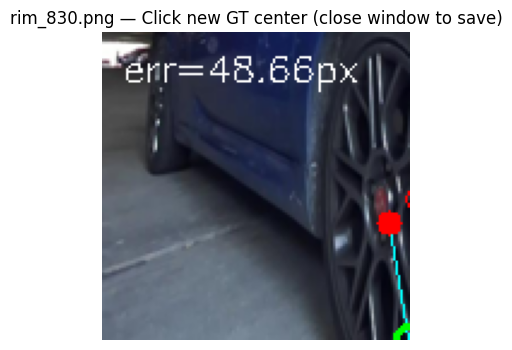

In [4]:
import json

# Load existing corrections if any
if corrected_labels_csv.exists():
    corrected_df = pd.read_csv(corrected_labels_csv)
    corrected = {r["filename"]: (int(r["new_gt_x"]), int(r["new_gt_y"])) for _, r in corrected_df.iterrows()}
    print(f"Loaded {len(corrected)} existing corrections.")
else:
    corrected = {}
    print("No existing corrections found.")

def load_base_image(fname, desired_size=(128, 128)):
    """
    Try to load original image and resize to match eval frame (128x128).
    If not available, fall back to overlay image.
    """
    base = None
    orig_path = img_dir / fname
    if orig_path.exists():
        base = cv2.imread(str(orig_path))
        if base is not None:
            base = cv2.resize(base, desired_size, interpolation=cv2.INTER_LINEAR)

    if base is None:
        # Fallback: use overlay (already 128x128 with GT/Pred)
        overlay_path = overlays_dir / f"overlay_{Path(fname).name}"
        base = cv2.imread(str(overlay_path))

    return base

def show_and_collect_click(img_bgr, gx=None, gy=None, px=None, py=None, title="Click new GT center"):
    """
    Shows the image with optional GT/Pred markers and collects one click.
    Returns (x, y) in image coordinates, or None if no click.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()

    # Draw existing GT/Pred if provided
    vis = img_rgb.copy()
    if gx is not None and gy is not None:
        cv2.circle(vis, (int(gx), int(gy)), 5, (255, 0, 0), -1)  # GT red-ish
    if px is not None and py is not None:
        cv2.circle(vis, (int(px), int(py)), 5, (0, 255, 0), 2)   # Pred green ring

    fig, ax = plt.subplots()
    ax.imshow(vis)
    ax.set_title(title)
    ax.axis("off")

    clicks = plt.ginput(1, timeout=0)  # wait indefinitely for a single click
    plt.close(fig)

    if clicks:
        x, y = clicks[0]
        return int(round(x)), int(round(y))
    return None

# Iterate drift cases and collect corrections
pending = 0
for _, r in drift_eval.iterrows():
    fname = r["filename"]
    if fname in corrected:
        continue  # already labeled

    gx, gy = r["gt_x"], r["gt_y"]
    px, py = r["pred_x"], r["pred_y"]

    img = load_base_image(fname)
    if img is None:
        print(f"Could not load any image for {fname}, skipping.")
        continue

    new_pt = show_and_collect_click(
        img_bgr=img, gx=gx, gy=gy, px=px, py=py,
        title=f"{fname} — Click new GT center (close window to save)"
    )

    if new_pt is None:
        print(f"Skipped: {fname}")
        continue

    nx, ny = new_pt
    corrected[fname] = (nx, ny)
    pending += 1

    # Save incrementally
    corr_records = [{"filename": k, "new_gt_x": v[0], "new_gt_y": v[1]} for k, v in corrected.items()]
    pd.DataFrame(corr_records).to_csv(corrected_labels_csv, index=False)

print(f"Done. Collected {pending} new corrections.")
print(f"Saved corrections to: {corrected_labels_csv}")


# Merge corrected labels into training labels

In [ ]:
# Load original train labels
orig = pd.read_csv(train_labels_csv)
print(f"Loaded {len(orig)} training labels.")

# Load corrections
if not corrected_labels_csv.exists():
    raise FileNotFoundError(f"No corrected labels found at {corrected_labels_csv}. Run the relabeling step first.")
corr = pd.read_csv(corrected_labels_csv)

# Merge
merged = orig.merge(corr, on="filename", how="left")

# Replace gt_x, gt_y where corrections exist
merged["gt_x"] = np.where(merged["new_gt_x"].notna(), merged["new_gt_x"].astype(int), merged["gt_x"])
merged["gt_y"] = np.where(merged["new_gt_y"].notna(), merged["new_gt_y"].astype(int), merged["gt_y"])

# Drop helper columns
merged = merged.drop(columns=[c for c in ["new_gt_x", "new_gt_y"] if c in merged.columns])

# Save
merged.to_csv(updated_train_labels_csv, index=False)
print(f"Updated training labels saved to: {updated_train_labels_csv}")


# Quick sanity check visualization

In [ ]:
check = corr.sample(min(5, len(corr)), random_state=0) if len(corr) else pd.DataFrame()
for _, r in check.iterrows():
    fname = r["filename"]
    nx, ny = int(r["new_gt_x"]), int(r["new_gt_y"])
    img = cv2.imread(str(img_dir / fname)) if (img_dir / fname).exists() else None
    if img is None:
        img = cv2.imread(str(overlays_dir / f"overlay_{Path(fname).name}"))
    if img is None:
        continue

    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)
    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cv2.circle(vis, (nx, ny), 5, (255, 0, 0), -1)
    plt.imshow(vis)
    plt.title(f"{fname} — new GT: ({nx},{ny})")
    plt.axis("off")
    plt.show()
